In [1]:
import pandas as pd

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import  silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage 
from scipy.cluster.hierarchy import dendrogram
from yellowbrick.cluster import SilhouetteVisualizer


In [4]:
import datetime

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, MinMaxScaler, FunctionTransformer

In [6]:
from sklearn.decomposition import PCA



In [7]:
file = r'/Users/nikosap/Desktop/ML_bootcamp/14.GitHubProject2/energy_utilities_sim.csv'

In [8]:
df = pd.read_csv(file)

In [9]:
df

,user_id,average_daily_consumption,average_days_to_bill_payment,customer_since,area,age,marital_status,educational_level,prefecture,average_monthly_visits,average_web_monthly_visits,average_mobile_monthly_visits
0,1,7.797533,-33.932899,2015-05-14,136.200805,40-55,Married,Master’s degree,Neon-Attika,0.865182,0.538854,0.330131
1,2,25.068224,-3.213220,2015-06-02,97.656313,30-39,Married,Bachelor’s degree,Corinthus Crossroads,4.154858,0.697384,3.491964
2,3,7.875073,16.366928,2015-06-29,133.072322,40-55,Married,Master’s degree,Neon-Attika,2.819235,2.394294,0.560970
3,4,12.309787,-2.479825,2015-03-19,88.884085,40-55,Married,Master’s degree,Neon-Attika,0.852767,0.569274,0.238127
4,5,8.888037,14.005530,2014-08-22,64.459468,30-39,Married,Bachelor’s degree,Evoa Conglomerate,11.056524,3.527665,7.131606
...,...,...,...,...,...,...,...,...,...,...,...,...
1248,1249,36.049991,7.913366,2017-01-05,101.345573,30-39,Married,Master’s degree,Chanion Underhive,33.277992,2.605684,30.750945
1249,1250,12.912167,0.000000,2017-01-11,87.722475,40-55,Married,"High school graduate, diploma or the equivalent",Evrax,7.630204,2.578579,4.768062
1250,1251,42.633626,12.018915,2017-01-11,81.664547,40-55,Married,Bachelor’s degree,Rethyx-Pterax,13.177438,1.446155,11.965140
1251,1252,49.460804,5.011639,2017-01-12,120.466909,30-39,Married,"High school graduate, diploma or the equivalent",Kavallon,39.063468,4.521204,36.102688


In [10]:
df.columns

Index(['user_id', 'average_daily_consumption', 'average_days_to_bill_payment',
       'customer_since', 'area', 'age', 'marital_status', 'educational_level',
       'prefecture', 'average_monthly_visits', 'average_web_monthly_visits',
       'average_mobile_monthly_visits'],
      dtype='object')

In [11]:
cols_to_drop = ['prefecture', 'average_monthly_visits']

In [12]:
df_dr = df.copy().drop(columns=cols_to_drop)

In [13]:
area_mask = df_dr[df_dr['area']==0]

In [14]:
area_mask.index

Index([14, 91, 387, 459, 573, 663, 754, 776, 889, 980], dtype='int64')

In [15]:
df_new = df_dr.copy().drop(index=area_mask.index)

In [16]:
df_new.head()

,user_id,average_daily_consumption,average_days_to_bill_payment,customer_since,area,age,marital_status,educational_level,average_web_monthly_visits,average_mobile_monthly_visits
0,1,7.797533,-33.932899,2015-05-14,136.200805,40-55,Married,Master’s degree,0.538854,0.330131
1,2,25.068224,-3.213220,2015-06-02,97.656313,30-39,Married,Bachelor’s degree,0.697384,3.491964
2,3,7.875073,16.366928,2015-06-29,133.072322,40-55,Married,Master’s degree,2.394294,0.560970
3,4,12.309787,-2.479825,2015-03-19,88.884085,40-55,Married,Master’s degree,0.569274,0.238127
4,5,8.888037,14.005530,2014-08-22,64.459468,30-39,Married,Bachelor’s degree,3.527665,7.131606


In [17]:
df_new['days_since'] = (pd.Timestamp.today() - pd.to_datetime(df_new['customer_since'])).dt.days

In [18]:
df_new['days_since']

0       4153
1       4134
2       4107
3       4209
4       4418
        ... 
1248    3551
1249    3545
1250    3545
1251    3544
1252    3544
Name: days_since, Length: 1243, dtype: int64

In [19]:
df_new['area'] = df_new['area'].round(1)

In [20]:
print(df_new['age'].value_counts())

age
30-39            509
40-55            504
19-29            130
56-67             78
68+               20
18 or younger      2
Name: count, dtype: int64


In [21]:
df_new['age'] = df_new['age'].replace('18 or younger', '19-29')

In [22]:
df_new['age'].value_counts()

age
30-39    509
40-55    504
19-29    132
56-67     78
68+       20
Name: count, dtype: int64

In [23]:
df_new['marital_status'].value_counts()

marital_status
Married     906
Single      273
Divorced     48
Widowed      16
Name: count, dtype: int64

In [24]:
df_new['marital_status'] = df_new['marital_status'].replace('Widowed', 'Divorced')

In [25]:
df_new['educational_level'].value_counts()

educational_level
Bachelor’s degree                                  511
High school graduate, diploma or the equivalent    437
Master’s degree                                    238
Doctorate degree                                    29
No degree                                           28
Name: count, dtype: int64

In [26]:
df_new['educational_level'] = df_new['educational_level'].replace('No degree', 'High school graduate, diploma or the equivalent')
df_new['educational_level'] = df_new['educational_level'].replace('Master’s degree', 'Advanced degree')
df_new['educational_level'] = df_new['educational_level'].replace('Doctorate degree', 'Advanced degree')

In [27]:
df_new['educational_level'].value_counts()

educational_level
Bachelor’s degree                                  511
High school graduate, diploma or the equivalent    465
Advanced degree                                    267
Name: count, dtype: int64

In [28]:
df_new= df_new.drop(columns='customer_since')

In [29]:
df_new.columns

Index(['user_id', 'average_daily_consumption', 'average_days_to_bill_payment',
       'area', 'age', 'marital_status', 'educational_level',
       'average_web_monthly_visits', 'average_mobile_monthly_visits',
       'days_since'],
      dtype='object')

In [30]:
ordinal_cols = ['educational_level', 'age']
categorical_cols = ['marital_status']
numerical_cols = ['average_daily_consumption', 'average_days_to_bill_payment','area','average_web_monthly_visits', 'average_mobile_monthly_visits',
       'days_since']

In [31]:
df_new['educational_level'].unique()

array(['Advanced degree', 'Bachelor’s degree',
       'High school graduate, diploma or the equivalent'], dtype=object)

In [32]:
age_order = [
    '19-29',
    '30-39',
    '40-55',
    '56-67',
    '68+'
]

education_order = [
    'High school graduate, diploma or the equivalent',
    'Bachelor’s degree',
    'Advanced degree'
]

In [33]:
# numeric_features = ["age", "fare"]
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())]
)

# categorical_features = ["embarked", "sex", "pclass"]
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(sparse_output=False))
    ]
)

oridnal_transformer = Pipeline(
    steps=[('ord_end', OrdinalEncoder(categories=[education_order,age_order]))]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("ord", oridnal_transformer, ordinal_cols)
    ]
)

In [34]:
eng_pipe = Pipeline(
    steps=[("preprocessor", preprocessor)]).set_output(transform="pandas")

In [90]:
df_eng = eng_pipe.fit_transform(df_new)

In [36]:
df_eng

,num__average_daily_consumption,num__average_days_to_bill_payment,num__area,num__average_web_monthly_visits,num__average_mobile_monthly_visits,num__days_since,cat__marital_status_Divorced,cat__marital_status_Married,cat__marital_status_Single,ord__educational_level,ord__age
0,-0.474632,-3.804806,0.647847,-0.583328,-0.781744,2.687351,0.0,1.0,0.0,2.0,2.0
1,0.542299,-0.691735,-0.040585,-0.531358,-0.471994,2.565772,0.0,1.0,0.0,1.0,1.0
2,-0.470066,1.292478,0.592415,0.024933,-0.759130,2.393001,0.0,1.0,0.0,2.0,2.0
3,-0.208942,-0.617414,-0.197941,-0.573356,-0.790757,3.045689,0.0,1.0,0.0,2.0,2.0
4,-0.410421,1.053178,-0.634245,0.396482,-0.115436,4.383058,0.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1248,1.188926,0.435811,0.023788,0.094232,2.198436,-1.164784,0.0,1.0,0.0,2.0,1.0
1249,-0.173473,-0.366114,-0.219398,0.085347,-0.346981,-1.203178,0.0,1.0,0.0,0.0,2.0
1250,1.576583,0.851859,-0.326686,-0.285891,0.358082,-1.203178,0.0,1.0,0.0,1.0,2.0
1251,1.978580,0.141756,0.367110,0.722190,2.722720,-1.209576,0.0,1.0,0.0,0.0,1.0


In [37]:
EPS = 0.5
MIN_SAMPLE = 30

In [38]:
dbscab = DBSCAN(eps=EPS, min_samples=MIN_SAMPLE)

In [39]:
db = dbscab.fit(df_eng)
db_label = db.labels_

In [40]:
# df_eng['db_label_default'] = db_label

In [41]:
# # Number of clusters in labels, ignoring noise if present.
# n_clusters_ = len(set(db_label)) - (1 if -1 in db_label else 0)
# n_noise_ = list(db_label).count(-1)

# print("Estimated number of clusters: %d" % n_clusters_)
# print("Estimated number of noise points: %d" % n_noise_)


Estimated number of clusters: 0
Estimated number of noise points: 1243


In [40]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [41]:
# def dbscan_interactive(eps=0.5, min_samples=5):

#     clear_output(wait=True)

#     # -------------------------
#     # DBSCAN
#     # -------------------------
#     model = DBSCAN(
#         eps=eps,
#         min_samples=min_samples
#     )

#     labels = model.fit_predict(df_eng)

#     # Number of clusters, excluding noise
#     n_clusters = len(set(labels) - {-1})

#     noise_pct = np.mean(labels == -1) * 100

#     print(f"eps:             {eps:.2f}")
#     print(f"min_samples:     {min_samples}")
#     print(f"clusters:        {n_clusters}")
#     print(f"noise:            {noise_pct:.1f}%")

#     # -------------------------
#     # Silhouette
#     # -------------------------
#     if n_clusters >= 2:

#         mask = labels != -1

#         X_clustered = df_eng[mask]
#         labels_clustered = labels[mask]

#         silhouette = silhouette_score(
#             X_clustered,
#             labels_clustered
#         )

#         print(f"silhouette:       {silhouette:.3f}")

#         # Yellowbrick silhouette plot
#         fig, ax = plt.subplots(figsize=(8, 5))

#         visualizer = SilhouetteVisualizer(
#             DBSCAN(
#                 eps=eps,
#                 min_samples=min_samples
#             ),
#             ax=ax
#         )

#         visualizer.fit(X_clustered)

#         ax.set_title(
#             f"Silhouette Plot — "
#             f"{n_clusters} clusters"
#         )

#         plt.show()

#     else:

#         print("Silhouette cannot be calculated: fewer than 2 clusters.")

#     # -------------------------
#     # PCA visualization
#     # -------------------------
#     X_pca = PCA(n_components=2).fit_transform(df_eng)

#     plt.figure(figsize=(8, 6))

#     plt.scatter(
#         X_pca[:, 0],
#         X_pca[:, 1],
#         c=labels,
#         cmap="tab10",
#         s=15,
#         alpha=0.7
#     )

#     plt.xlabel("PC1")
#     plt.ylabel("PC2")

#     plt.title(
#         f"DBSCAN clustering — "
#         f"{n_clusters} clusters"
#     )

#     plt.show()

In [42]:
# eps_slider = widgets.FloatSlider(
#     value=0.5,
#     min=0.05,
#     max=2.0,
#     step=0.05,
#     description="eps:",
#     continuous_update=False
# )

# min_samples_slider = widgets.IntSlider(
#     value=5,
#     min=2,
#     max=30,
#     step=1,
#     description="min_samples:",
#     continuous_update=False
# )

# widgets.interact(
#     dbscan_interactive,
#     eps=eps_slider,
#     min_samples=min_samples_slider
# )

In [43]:
from sklearn.kernel_approximation import Nystroem

In [44]:
# kernel = Nystroem(
#     kernel="poly",
#     gamma=0.1,
#     n_components=20,
#     random_state=42
# )

# X_kernel = kernel.fit_transform(df_eng)

In [45]:

# # ============================================================
# # Imports
# # ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
# from sklearn.decomposition import PCA

import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import clear_output


pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_eng)


# ============================================================
# Silhouette plot
# ============================================================

def plot_silhouette(X, labels, n_clusters):

    mask = labels != -1

    X_clustered = X[mask]
    labels_clustered = labels[mask]

    silhouette_values = silhouette_samples(
        X_clustered,
        labels_clustered
    )

    silhouette_avg = silhouette_values.mean()

    fig, ax = plt.subplots(figsize=(8, 5))

    y_lower = 10

    for cluster in sorted(np.unique(labels_clustered)):

        cluster_values = silhouette_values[
            labels_clustered == cluster
        ]

        cluster_values.sort()

        cluster_size = len(cluster_values)

        y_upper = y_lower + cluster_size

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_values,
            alpha=0.7
        )

        ax.text(
            -0.05,
            y_lower + 0.5 * cluster_size,
            str(cluster)
        )

        y_lower = y_upper + 10

    ax.axvline(
        silhouette_avg,
        linestyle="--",
        label=f"Average = {silhouette_avg:.3f}"
    )

    ax.set_title(
        f"Silhouette Plot — {n_clusters} clusters"
    )

    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")

    ax.legend()

    plt.tight_layout()
    plt.show()
# ============================================================ # 2. Output area # ============================================================ 
    
output = widgets.Output()

def dbscan_interactive(
    eps=0.5,
    min_samples=5
):

    with output:

        clear_output(wait=True)

        # -----------------------------
        # DBSCAN
        # -----------------------------

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric='manhattan'
        )

        labels = dbscan.fit_predict(df_eng)

        # -----------------------------
        # Cluster statistics
        # -----------------------------
        
        total_samples = len(labels)

        noise_mask = labels == -1

        noise_samples = np.sum(noise_mask)

        clustered_samples = total_samples - noise_samples

        noise_percentage = (
            noise_samples / total_samples
        ) * 100

        cluster_labels = sorted(
            set(labels) - {-1}
        )

        n_clusters = len(cluster_labels)

        print("=" * 60)
        print("DBSCAN RESULTS")
        print("=" * 60)

        print(f"eps:                  {eps:.3f}")
        print(f"min_samples:          {min_samples}")
        print(f"total samples:        {total_samples:,}")
        print(f"samples in clusters:  {clustered_samples:,}")
        print(f"noise samples:        {noise_samples:,}")
        print(f"noise percentage:     {noise_percentage:.2f}%")
        print(f"number of clusters:   {n_clusters}")

        print("=" * 60)
        print("PCA Variance")
        print("=" * 60)
        
        # Explained variance
        explained_variance = pca.explained_variance_ratio_ * 100

        print(
            f"PCA variance explained: "
            f"PC1 = {explained_variance[0]:.2f}%, "
            f"PC2 = {explained_variance[1]:.2f}%"
        )
        
        print(
            f"Total variance explained by PC1 + PC2: "
            f"{explained_variance.sum():.2f}%"
        )

        # -----------------------------
        # Silhouette
        # -----------------------------

        if n_clusters >= 2:

            mask = labels != -1

            X_clustered = df_eng[mask]
            labels_clustered = labels[mask]

            silhouette = silhouette_score(
                X_clustered,
                labels_clustered
            )

            print("=" * 60)
            print("Silhouette Score")
            print("=" * 60)

            print(
                f"silhouette:       {silhouette:.3f}"
            )

            print("=" * 50)

            # Silhouette plot
            plot_silhouette(
                df_eng,
                labels,
                n_clusters
            )

        else:

            print("silhouette:       N/A")

            print("=" * 50)

            print(
                "Silhouette score requires "
                "at least 2 clusters."
            )

        # -----------------------------
        # PCA plot
        # -----------------------------

        plt.figure(figsize=(8, 6))

        plt.scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            c=labels,
            cmap="tab10",
            s=15,
            alpha=0.7
        )

        plt.xlabel("PC1")
        plt.ylabel("PC2")

        plt.title(
            f"DBSCAN — "
            f"{n_clusters} clusters | "
            f"Noise = {noise_percentage:.1f}%"
        )

        plt.tight_layout()
        plt.show()


# ---------------------------------------------------------
# Sliders
# ---------------------------------------------------------

eps_slider = widgets.FloatSlider(
    value=0.5,
    min=0.05,
    max=5.0,
    step=0.1,
    description="eps:",
    continuous_update=False,
    readout_format=".2f",
    style={
        "description_width": "100px"
    },
    layout=widgets.Layout(
        width="500px"
    )
)


min_samples_slider = widgets.IntSlider(
    value=5,
    min=2,
    max=50,
    step=5,
    description="min_samples:",
    continuous_update=False,
    style={
        "description_width": "100px"
    },
    layout=widgets.Layout(
        width="500px"
    )
)



# ---------------------------------------------------------
# Update function
# ---------------------------------------------------------

def update_dbscan(change=None):

    dbscan_interactive(
        eps=eps_slider.value,
        min_samples=min_samples_slider.value
    )


# ---------------------------------------------------------
# Connect sliders
# ---------------------------------------------------------

eps_slider.observe(
    update_dbscan,
    names="value"
)

min_samples_slider.observe(
    update_dbscan,
    names="value"
)


# ---------------------------------------------------------
# Display widgets
# ---------------------------------------------------------

display(
    widgets.VBox([
        eps_slider,
        min_samples_slider,
        output
    ])
)


# ---------------------------------------------------------
# Initial plot
# ---------------------------------------------------------

update_dbscan()

In [95]:
db_final = DBSCAN(eps=2.15, min_samples=12)

In [98]:
df_eng.columns

Index(['num__average_daily_consumption', 'num__average_days_to_bill_payment',
       'num__area', 'num__average_web_monthly_visits',
       'num__average_mobile_monthly_visits', 'num__days_since',
       'cat__marital_status_Divorced', 'cat__marital_status_Married',
       'cat__marital_status_Single', 'ord__educational_level', 'ord__age'],
      dtype='object')

In [96]:
labels_final = db_final.fit_predict(df_eng)

In [97]:
np.unique(labels_final)

array([-1,  0])

In [99]:
df_eng['db_final_label']=labels_final

In [100]:
df_eng['db_final_label'].value_counts()

db_final_label
 0    1160
-1      83
Name: count, dtype: int64

In [101]:
df_eng

,num__average_daily_consumption,num__average_days_to_bill_payment,num__area,num__average_web_monthly_visits,num__average_mobile_monthly_visits,num__days_since,cat__marital_status_Divorced,cat__marital_status_Married,cat__marital_status_Single,ord__educational_level,ord__age,db_final_label
0,-0.474632,-3.804806,0.647847,-0.583328,-0.781744,2.687351,0.0,1.0,0.0,2.0,2.0,-1
1,0.542299,-0.691735,-0.040585,-0.531358,-0.471994,2.565772,0.0,1.0,0.0,1.0,1.0,0
2,-0.470066,1.292478,0.592415,0.024933,-0.759130,2.393001,0.0,1.0,0.0,2.0,2.0,0
3,-0.208942,-0.617414,-0.197941,-0.573356,-0.790757,3.045689,0.0,1.0,0.0,2.0,2.0,0
4,-0.410421,1.053178,-0.634245,0.396482,-0.115436,4.383058,0.0,1.0,0.0,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1248,1.188926,0.435811,0.023788,0.094232,2.198436,-1.164784,0.0,1.0,0.0,2.0,1.0,0
1249,-0.173473,-0.366114,-0.219398,0.085347,-0.346981,-1.203178,0.0,1.0,0.0,0.0,2.0,0
1250,1.576583,0.851859,-0.326686,-0.285891,0.358082,-1.203178,0.0,1.0,0.0,1.0,2.0,0
1251,1.978580,0.141756,0.367110,0.722190,2.722720,-1.209576,0.0,1.0,0.0,0.0,1.0,0


In [102]:
df_eng.columns

Index(['num__average_daily_consumption', 'num__average_days_to_bill_payment',
       'num__area', 'num__average_web_monthly_visits',
       'num__average_mobile_monthly_visits', 'num__days_since',
       'cat__marital_status_Divorced', 'cat__marital_status_Married',
       'cat__marital_status_Single', 'ord__educational_level', 'ord__age',
       'db_final_label'],
      dtype='object')

In [103]:
df_new.columns

Index(['user_id', 'average_daily_consumption', 'average_days_to_bill_payment',
       'area', 'age', 'marital_status', 'educational_level',
       'average_web_monthly_visits', 'average_mobile_monthly_visits',
       'days_since'],
      dtype='object')

In [104]:


colors = {
    -1: 'red',
     0: 'blue',
     1: 'green'
}


In [105]:
columns = ['average_daily_consumption', 'average_days_to_bill_payment',
       'area', 'age', 'marital_status', 'educational_level',
       'average_web_monthly_visits', 'average_mobile_monthly_visits',
       'days_since']

In [106]:
X_pca_df = pd.DataFrame(X_pca)

In [107]:
X_pca_df.columns = ['PC1', 'PC2']

In [108]:
# pca_cols = 

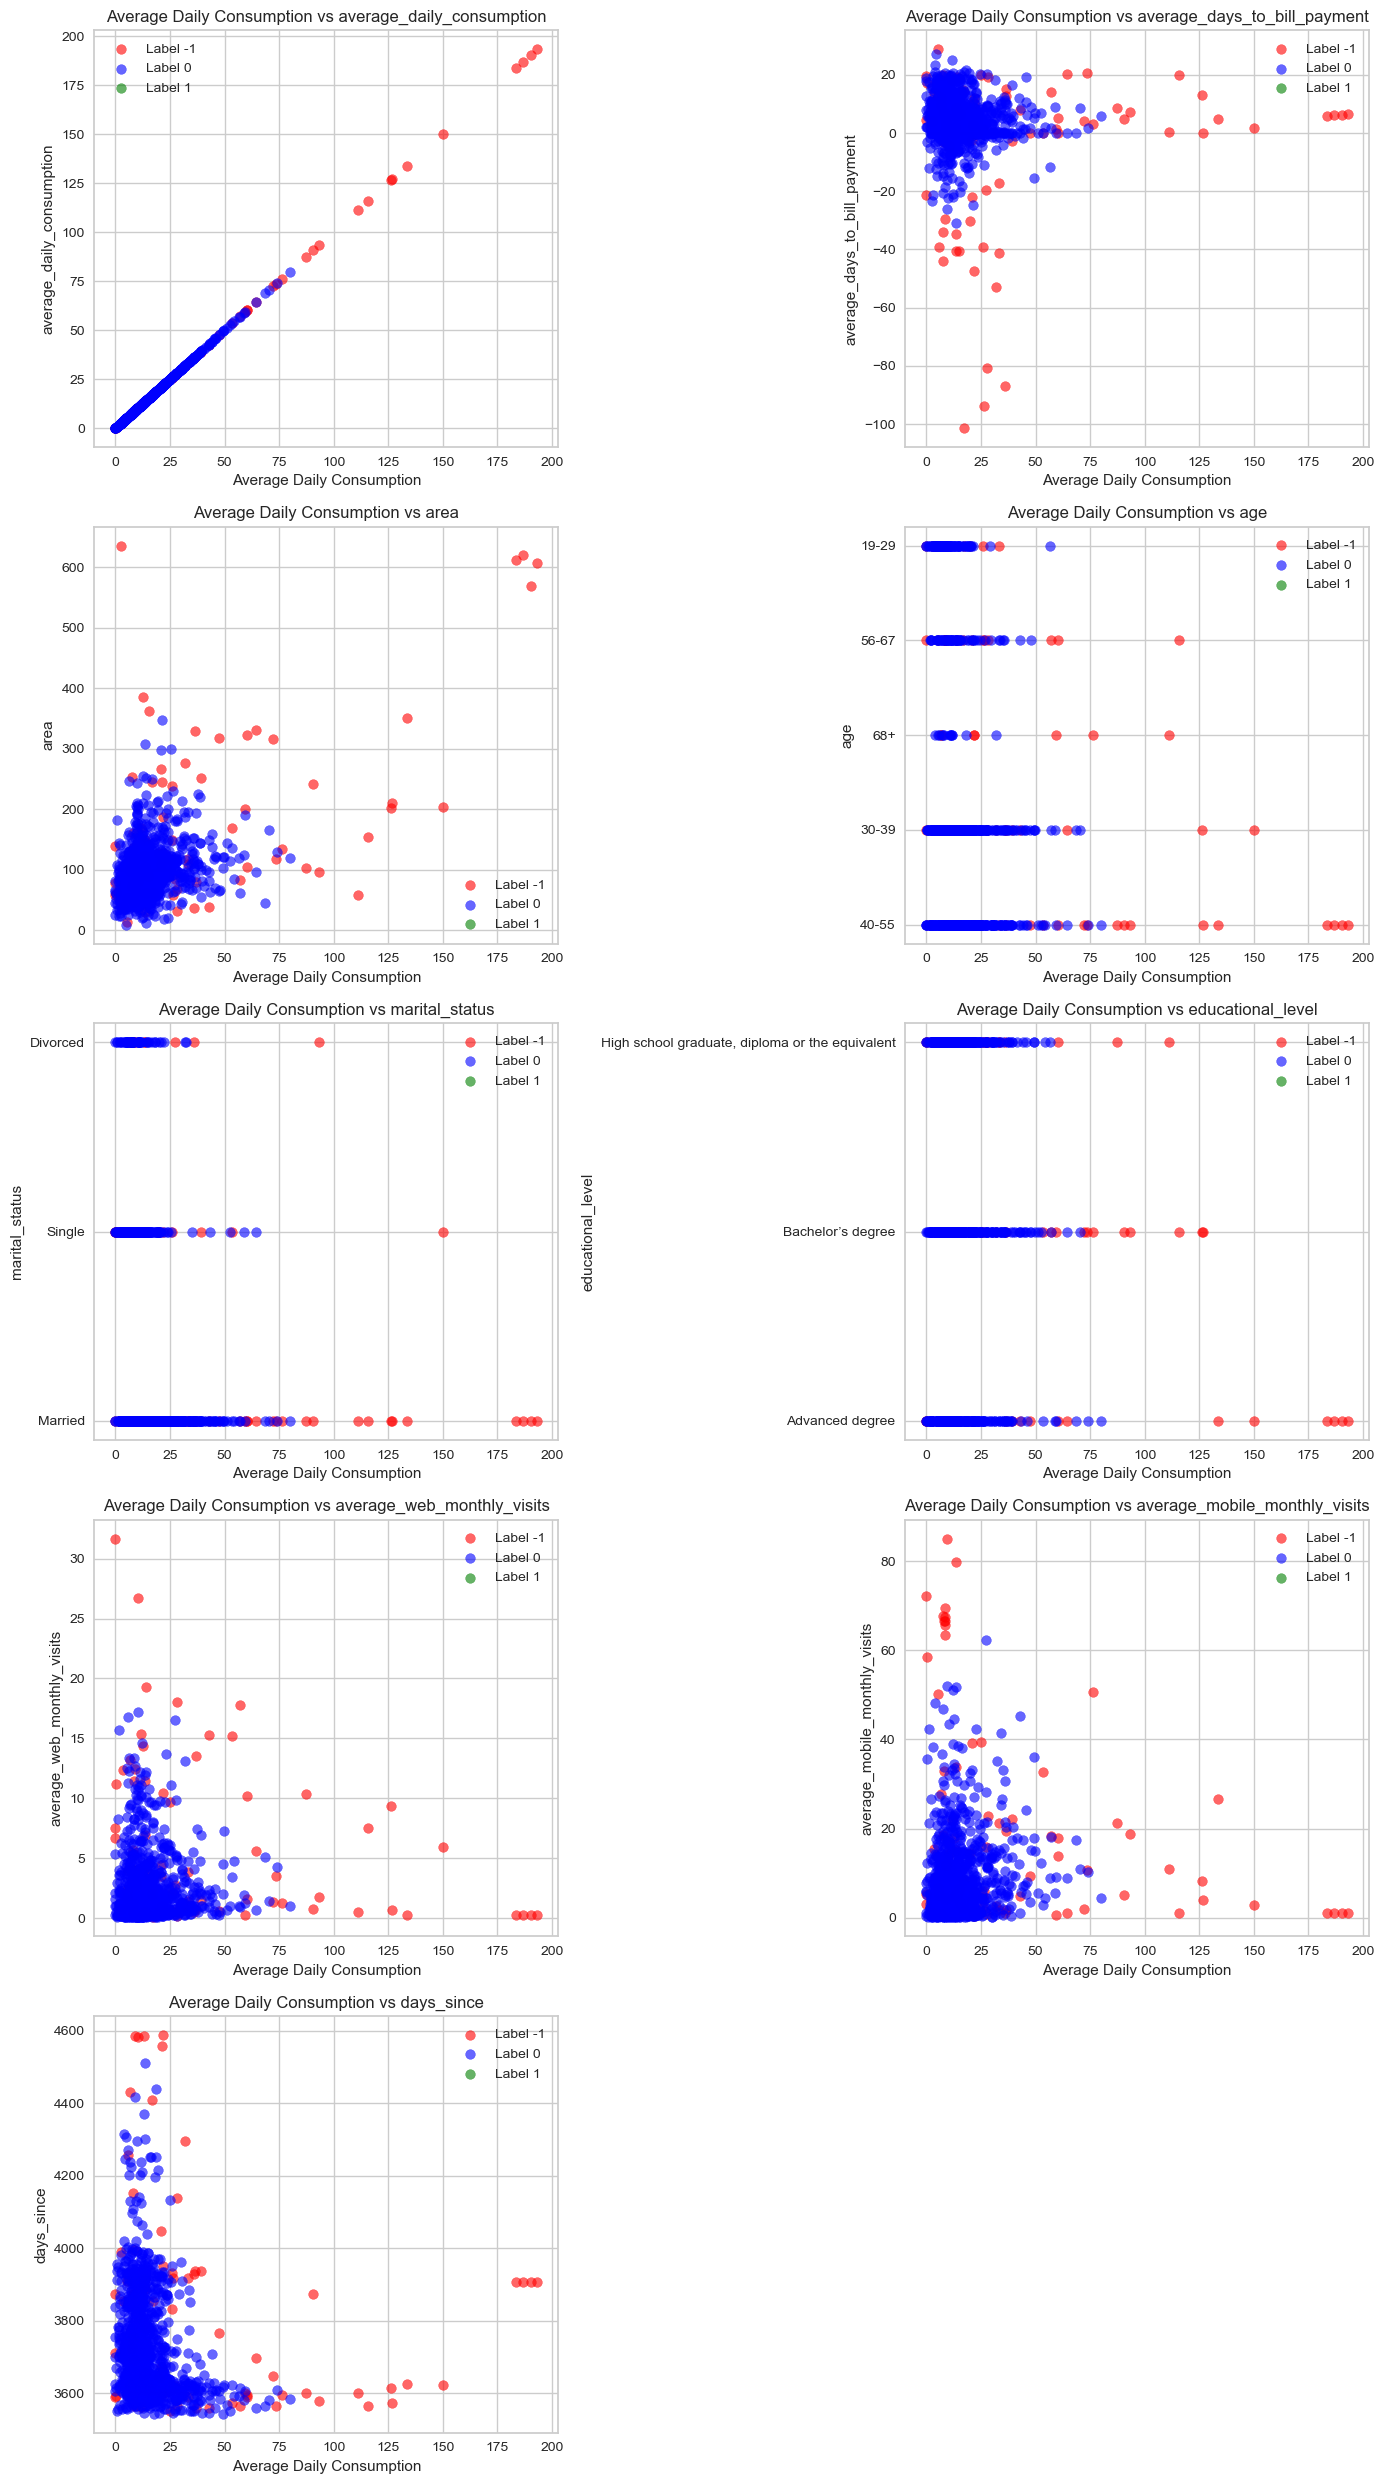

In [109]:
import matplotlib.pyplot as plt
import math

colors = {
    -1: 'red',
     0: 'blue',
     1: 'green'
}

n_cols = 2
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

# Make axes always iterable
axes = axes.flatten()

for ax, y_col in zip(axes, columns):

    for label in [-1, 0, 1]:
        mask = df_eng['db_final_label'] == label

        ax.scatter(
            df_new.loc[mask, 'average_daily_consumption'],
            df_new.loc[mask, y_col],
            c=colors[label],
            label=f'Label {label}',
            alpha=0.6
        )

    ax.set_xlabel('Average Daily Consumption')
    ax.set_ylabel(y_col)
    ax.set_title(f'Average Daily Consumption vs {y_col}')
    ax.legend()

# Remove unused subplots
for ax in axes[len(columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()